# **0. Import Library**

In [2]:
!pip install osm_flex
!pip install climada
!pip install fiona

from shapely.validation import make_valid
import osm_flex.download
import osm_flex.extract
import osm_flex.simplify as sy
from climada.entity import Exposures
from shapely.geometry import Polygon
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# **1. Climada OSM (building category), assing USS 200k, 100k and 50k as a single building value for Austria, Czech and Poland**

#**1.1 Get Poland Buidling Exposure data from OSM**

In [ ]:
iso3 = "POL" # input the iso3 code
path_ctr_dump = osm_flex.download.get_country_geofabrik(iso3)

shapefile_path = "POL_adm0.shp" # input the shape file
gdf = gpd.read_file(shapefile_path)

# List of infrastructure sectors
# sectors = ['education', 'healthcare', 'water', 'telecom', 'road', 'main_road', 'rail', 'air', 'gas', 'oil', 'power', 'wastewater', 'food', 'buildings']
sectors = ['buildings']

# Loop through each sector
for sector in sectors:
    try:
        # Extract critical infrastructure data with dynamic variable name
        gdf_sector = osm_flex.extract.extract_cis(path_ctr_dump, sector)

        # Set CRS to EPSG:4326
        gdf_sector = gdf_sector.to_crs(epsg=4326)

        # Check for invalid geometries (optional, for debugging)
        invalid_count = (~gdf_sector.is_valid).sum()
        if invalid_count > 0:
            print(f"Found {invalid_count} invalid geometries in {sector} data. Repairing...")

        # Repair invalid geometries
        gdf_sector['geometry'] = gdf_sector['geometry'].apply(make_valid)

        # Optionally repair the clip mask
        gdf['geometry'] = gdf['geometry'].apply(make_valid)

        # Clip the GeoDataFrame
        gdf_sector = gdf_sector.clip(gdf)

        # Create Exposures object
        exp_sector = Exposures(gdf_sector)

        # Save to CSV
        output_file = f"{iso3}_{sector}_exposures.csv"
        exp_sector.gdf.to_csv(output_file, index=False)
        print(f"Saved {sector} exposures to {output_file}")
        '''
        # Create and save plot
        fig, ax = plt.subplots(figsize=(15, 15))
        gdf_sector.plot(ax=ax, alpha=1, markersize=5, color="blue", edgecolor="blue", label="Buildings Landuse")
        ax.legend(loc="upper left")
        ax.set_title(f"{sector}_exposures Example", fontsize=25)

        # Save plot as PNG
        plot_file = f"{sector}_exposures_plot.png"
        plt.savefig(plot_file, dpi=300, bbox_inches='tight')
        plt.close(fig)
        print(f"Saved {sector} plot to {plot_file}")'''


    except Exception as e:
        print(f"Error processing {sector}: {str(e)}")

/usr/local/lib/python3.11/dist-packages/osgeo/ogr.py:593: FutureWarning: Neither ogr.UseExceptions() nor ogr.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(
extract multipolygons: 100%|██████████| 14422040/14422040 [30:32<00:00, 7868.78it/s] 


# **1.2 Get Czech Buidling Exposure data from OSM**

In [ ]:
iso3 = "CZE" # input the iso3 code
path_ctr_dump = osm_flex.download.get_country_geofabrik(iso3)

shapefile_path = "CZE_adm0.shp" # input the shape file
gdf = gpd.read_file(shapefile_path)

# List of infrastructure sectors
# sectors = ['education', 'healthcare', 'water', 'telecom', 'road', 'main_road', 'rail', 'air', 'gas', 'oil', 'power', 'wastewater', 'food', 'buildings']
sectors = ['buildings']

# Loop through each sector
for sector in sectors:
    try:
        # Extract critical infrastructure data with dynamic variable name
        gdf_sector = osm_flex.extract.extract_cis(path_ctr_dump, sector)

        # Set CRS to EPSG:4326
        gdf_sector = gdf_sector.to_crs(epsg=4326)

        # Check for invalid geometries (optional, for debugging)
        invalid_count = (~gdf_sector.is_valid).sum()
        if invalid_count > 0:
            print(f"Found {invalid_count} invalid geometries in {sector} data. Repairing...")

        # Repair invalid geometries
        gdf_sector['geometry'] = gdf_sector['geometry'].apply(make_valid)

        # Optionally repair the clip mask
        gdf['geometry'] = gdf['geometry'].apply(make_valid)

        # Clip the GeoDataFrame
        gdf_sector = gdf_sector.clip(gdf)

        # Create Exposures object
        exp_sector = Exposures(gdf_sector)

        # Save to CSV
        output_file = f"{iso3}_{sector}_exposures.csv"
        exp_sector.gdf.to_csv(output_file, index=False)
        print(f"Saved {sector} exposures to {output_file}")

        # Create and save plot
        fig, ax = plt.subplots(figsize=(15, 15))
        gdf_sector.plot(ax=ax, alpha=1, markersize=5, color="blue", edgecolor="blue", label="Buildings Landuse")
        ax.legend(loc="upper left")
        ax.set_title(f"{sector}_exposures Example", fontsize=25)

        # Save plot as PNG
        plot_file = f"{sector}_exposures_plot.png"
        plt.savefig(plot_file, dpi=300, bbox_inches='tight')
        plt.close(fig)
        print(f"Saved {sector} plot to {plot_file}")


    except Exception as e:
        print(f"Error processing {sector}: {str(e)}")

/usr/local/lib/python3.11/dist-packages/osgeo/ogr.py:593: FutureWarning: Neither ogr.UseExceptions() nor ogr.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(
extract multipolygons: 100%|██████████| 3957819/3957819 [05:02<00:00, 13097.53it/s]


Found 1 invalid geometries in buildings data. Repairing...
Saved buildings exposures to CZE_buildings_exposures.csv


# **1.3 Get Austria Buidling Exposure data from OS**

In [ ]:
iso3 = "AUT" # input the iso3 code
path_ctr_dump = osm_flex.download.get_country_geofabrik(iso3)

shapefile_path = "AUT_adm0.shp" # input the shape file
gdf = gpd.read_file(shapefile_path)

# List of infrastructure sectors
# sectors = ['education', 'healthcare', 'water', 'telecom', 'road', 'main_road', 'rail', 'air', 'gas', 'oil', 'power', 'wastewater', 'food', 'buildings']
sectors = ['buildings']

# Loop through each sector
for sector in sectors:
    try:
        # Extract critical infrastructure data with dynamic variable name
        gdf_sector = osm_flex.extract.extract_cis(path_ctr_dump, sector)

        # Set CRS to EPSG:4326
        gdf_sector = gdf_sector.to_crs(epsg=4326)

        # Check for invalid geometries (optional, for debugging)
        invalid_count = (~gdf_sector.is_valid).sum()
        if invalid_count > 0:
            print(f"Found {invalid_count} invalid geometries in {sector} data. Repairing...")

        # Repair invalid geometries
        gdf_sector['geometry'] = gdf_sector['geometry'].apply(make_valid)

        # Optionally repair the clip mask
        gdf['geometry'] = gdf['geometry'].apply(make_valid)

        # Clip the GeoDataFrame
        gdf_sector = gdf_sector.clip(gdf)

        # Create Exposures object
        exp_sector = Exposures(gdf_sector)

        # Save to CSV
        output_file = f"{iso3}_{sector}_exposures.csv"
        exp_sector.gdf.to_csv(output_file, index=False)
        print(f"Saved {sector} exposures to {output_file}")

        # Create and save plot
        fig, ax = plt.subplots(figsize=(15, 15))
        gdf_sector.plot(ax=ax, alpha=1, markersize=5, color="blue", edgecolor="blue", label="Buildings Landuse")
        ax.legend(loc="upper left")
        ax.set_title(f"{sector}_exposures Example", fontsize=25)

        # Save plot as PNG
        plot_file = f"{sector}_exposures_plot.png"
        plt.savefig(plot_file, dpi=300, bbox_inches='tight')
        plt.close(fig)
        print(f"Saved {sector} plot to {plot_file}")


    except Exception as e:
        print(f"Error processing {sector}: {str(e)}")


extract multipolygons: 100%|██████████| 3904320/3904320 [05:11<00:00, 12537.11it/s]


Found 44 invalid geometries in buildings data. Repairing...
Saved buildings exposures to AUT_buildings_exposures.csv


# **2. Climada LitPop**

# **2.1 Get Poland exposure data from LitPop of 2020**

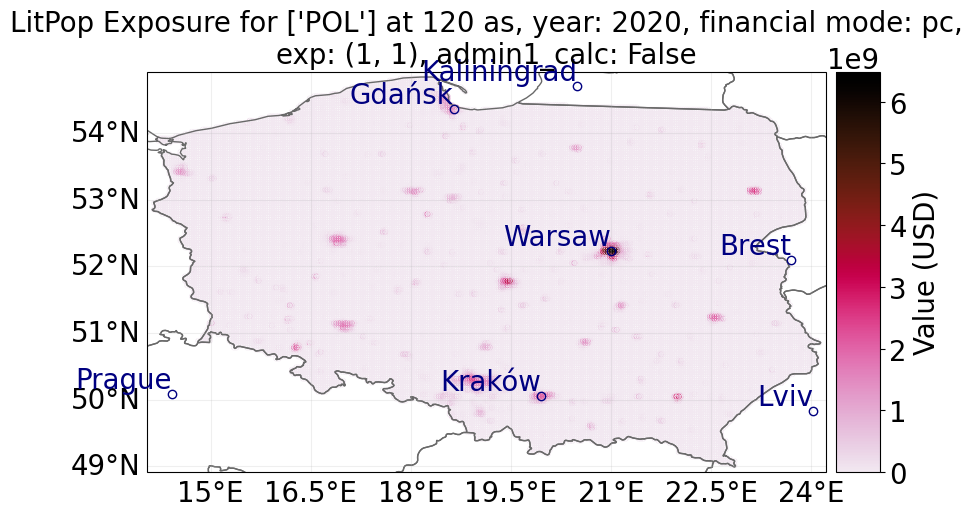

In [9]:
from climada.entity.exposures import LitPop

exp_lp = LitPop.from_countries(
    countries=["POL"], res_arcsec=120, reference_year=2020
)

exp_lp.plot_hexbin(pop_name=True, linewidth=4, buffer=0.1);
exp_lp.gdf.to_csv('Poland_exp_lp.csv')

In [8]:
print(exp_lp)

description: LitPop Exposure for ['POL'] at 120 as, year: 2020, financial mode: pc, exp: (1, 1), admin1_calc: False
ref_year: 2020
value_unit: USD
exponents: (1, 1)
fin_mode: pc
gpw_version: 11
crs: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
data: (37029 entries)
               value  region_id  impf_                   geometry
0      257480.938637        616      1     POINT (17.85 54.81667)
1       92109.130409        616      1  POINT (17.88333 54.81667)
2      114459.720865        616      1  POINT (17.91667 54.81667)
3      140080.521626        616      1     POINT (17.95 54.81667)
37025   58333.611109        616      1     POINT (22.78333 49.05)
37026   33243.154162        616      1     POINT (22.81667 49.05)
37027   64221.

# **2.2 Get Czech exposure data from LitPop of 2020**

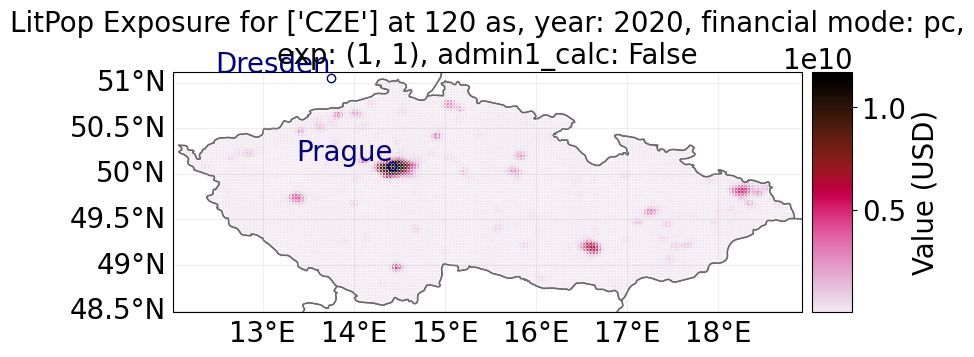

In [10]:
from climada.entity.exposures import LitPop

exp_lp = LitPop.from_countries(
    countries=["CZE"], res_arcsec=120, reference_year=2020
)

exp_lp.plot_hexbin(pop_name=True, linewidth=4, buffer=0.1);
exp_lp.gdf.to_csv('Czech_exp_lp.csv')

# **2.3 Get Austria exposure data from LitPop of 2020**

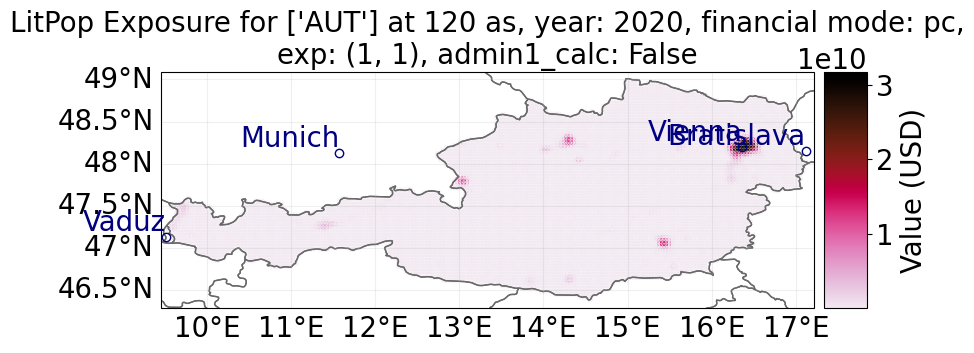

In [11]:
from climada.entity.exposures import LitPop

exp_lp = LitPop.from_countries(
    countries=["AUT"], res_arcsec=120, reference_year=2020
)

exp_lp.plot_hexbin(pop_name=True, linewidth=4, buffer=0.1);
exp_lp.gdf.to_csv('Austria_exp_lp.csv')

# **2.4 Get the Austria, Czech and Poland Exposure Data from LitPop of 2018**

In [12]:
from climada.entity import LitPop
from climada.util.api_client import Client

client = Client()

data_types = client.list_data_type_infos()

dtf = pd.DataFrame(data_types)

dtf.sort_values(["data_type_group", "data_type"])

litpop_dataset_infos = client.list_dataset_infos(data_type="litpop")
all_properties = client.get_property_values(litpop_dataset_infos)
all_properties.keys()

dict_keys(['res_arcsec', 'exponents', 'fin_mode', 'spatial_coverage', 'country_iso3alpha', 'country_name', 'country_iso3num'])

In [13]:
client.get_property_values(
    litpop_dataset_infos, known_property_values={"country_name": "Poland"}
)

{'res_arcsec': ['150'],
 'exponents': ['(3,0)', '(0,1)', '(1,1)'],
 'fin_mode': ['pc', 'pop'],
 'spatial_coverage': ['country'],
 'country_iso3alpha': ['POL'],
 'country_name': ['Poland'],
 'country_iso3num': ['616']}

**Czech should input: Czechia**

Enter the country name: Czechia
Number of available exponents: 3
Available exponents: [(3, 0), (0, 1), (1, 1)]
Saved plot: litpop_czechia_output/litpop_Czechia_exp_3_0.png
Saved CSV: litpop_czechia_output/litpop_czechia_exp_3_0.csv
Saved plot: litpop_czechia_output/litpop_Czechia_exp_0_1.png
Saved CSV: litpop_czechia_output/litpop_czechia_exp_0_1.csv
Saved plot: litpop_czechia_output/litpop_Czechia_exp_1_1.png
Saved CSV: litpop_czechia_output/litpop_czechia_exp_1_1.csv
Processing complete.


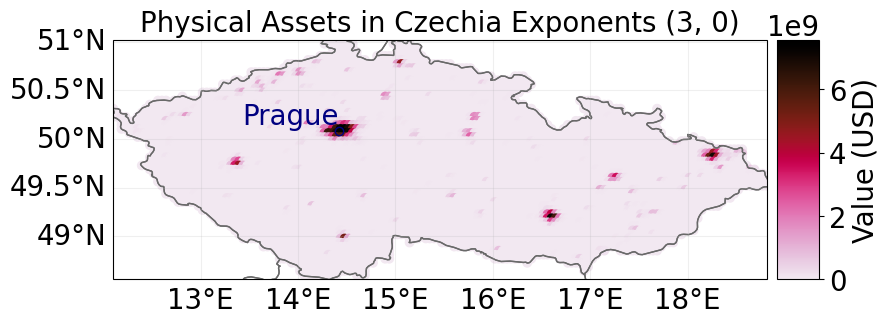

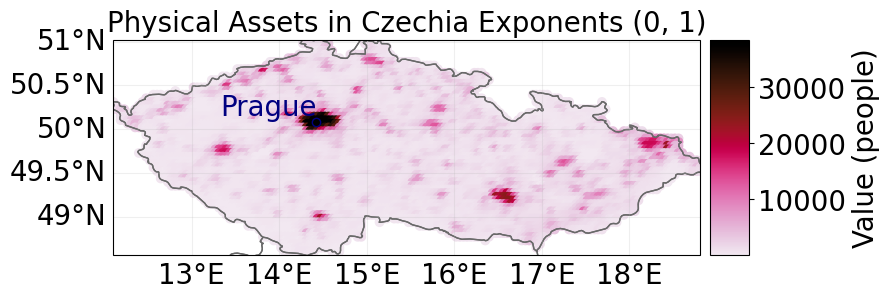

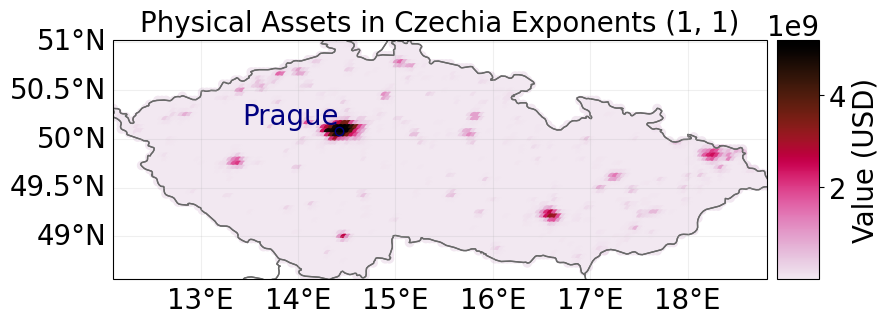

In [1]:
import os
from climada.util.api_client import Client
import matplotlib.pyplot as plt

# Initialize CLIMADA client
client = Client()

# Get user input for country name
country_name = input("Enter the country name: ").strip().capitalize()

# Get available exponents for Philippines
litpop_dataset_infos = client.list_dataset_infos(data_type="litpop")
prop_values = client.get_property_values(
    litpop_dataset_infos, known_property_values={"country_name": country_name}
)
if not prop_values.get('country_name'):
    print(f"No LitPop data available for {country_name}. Please try another country.")
    print("Check the website to find the correspond country name/n")
    print("download the Metadata countries (v.1.2) (CSV, 20.21Kb) file from https://www.research-collection.ethz.ch/handle/20.500.11850/331316")
    exit()
else:
    # Extract and parse exponents
    exponents_list = [eval(exp) for exp in prop_values['exponents']]
    print(f"Number of available exponents: {len(exponents_list)}")
    print(f"Available exponents: {exponents_list}")

    # Create output directory
    output_dir = f"litpop_{country_name.lower()}_output"
    os.makedirs(output_dir, exist_ok=True)

    # Iterate through each exponent pair
    for exp in exponents_list:
        try:
            # Retrieve LitPop data for the current exponent
            litpop = client.get_litpop(country=country_name, exponents=exp)

            # Create a two-line title for the plot
            plot_title = f"Physical Assets in {country_name} Exponents {exp}"

            # Plot and save the map
            fig, ax = plt.subplots(figsize=(10, 6))
            # Get a LitPop Exposures instance on a 150arcsec grid
            # with the default parameters: fin_mode = 'pc'
            litpop.plot_scatter(title=plot_title)
            plot_filename = f"{output_dir}/litpop_{country_name}_exp_{exp[0]}_{exp[1]}.png"
            plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
            plt.close(fig)
            print(f"Saved plot: {plot_filename}")



            # Save the exposure data as CSV
            csv_filename = f"{output_dir}/litpop_{country_name.lower()}_exp_{exp[0]}_{exp[1]}.csv"
            litpop.gdf.to_csv(csv_filename, index=False)
            print(f"Saved CSV: {csv_filename}")

        except Exception as e:
            print(f"Error processing exponents {exp}: {str(e)}")

    print("Processing complete.")

In [16]:
print(litpop)

description: LitPop Exposure for ['POL'] at 150 as, year: 2018, financial mode: pc, exp: (1, 1), admin1_calc: False
ref_year: 2018
value_unit: USD
crs: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
data: (23692 entries)
               value  region_id  impf_                   geometry
0      343998.754303        616      1   POINT (17.85417 54.8125)
1      157228.950014        616      1   POINT (17.89583 54.8125)
2      236752.805670        616      1    POINT (17.9375 54.8125)
3      263548.928484        616      1   POINT (17.97917 54.8125)
23688   63824.806243        616      1   POINT (22.77083 49.0625)
23689   48443.892801        616      1    POINT (22.8125 49.0625)
23690  117651.823757        616      1   POINT (22.8125 49.02083)
23691   78744.846935